# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,  mean_squared_error

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [16]:
df_cluster = pd.read_csv('hasil_clustering.csv')
df_cluster.head()

,latitude,longitude,depth,mag,cluster,magType
0,52.0999,178.5218,82.770,3.10,1,ml
1,7.1397,126.7380,79.194,4.50,0,mb
2,19.1631,-66.5251,24.000,3.93,2,md
3,-4.7803,102.7675,63.787,4.30,0,mb
4,53.3965,-166.9417,10.000,3.00,1,ml


# **3. Data Splitting**

In [18]:
# Definisikan fitur (X) dan target (y)
X = df_cluster.drop(columns=['cluster'])  # Menghapus kolom target dari fitur
y = df_cluster['cluster']  # Kolom target

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(19745, 5), y_train=(19745,)
Test set shape: X_test=(4937, 5), y_test=(4937,)


### Melakukan encoding dan standarisasi

In [20]:
# Memisahkan fitur numerik dan kategorikal
cat_features = X.select_dtypes(include=['object']).columns
num_features = X.select_dtypes(exclude=['object']).columns

# OneHotEncoding untuk fitur kategorikal
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[cat_features])
X_test_cat = encoder.transform(X_test[cat_features])

# Standard Scaling untuk fitur numerik
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_features])
X_test_num = scaler.transform(X_test[num_features])

# Menggabungkan keduanya 
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final = np.hstack((X_test_num, X_test_cat))

# Mengubah ke dataframe untu memvalidasi hasil
X_train_final_df = pd.DataFrame(X_train_final, columns=np.concatenate([num_features, encoder.get_feature_names_out(cat_features)]), index=X_train.index)
X_test_final_df = pd.DataFrame(X_test_final, columns=np.concatenate([num_features, encoder.get_feature_names_out(cat_features)]), index=X_test.index)

# Menampilkan hasil encoding dan scaling
X_train_final_df.head()
X_test_final_df.head()

,latitude,longitude,depth,mag,magType_mb,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_ml(texnet),magType_mlr,magType_mlv,magType_ms_vx,magType_mw,magType_mwb,magType_mwc,magType_mwr,magType_mww
15436,-1.285437,-0.417095,0.009215,0.165349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6061,-0.764403,1.108761,2.344424,0.288277,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3634,0.018865,-0.377418,-0.095602,-1.014752,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24474,-0.318099,1.103340,-0.013821,0.779986,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8361,1.175772,-1.144951,-0.289308,-1.432705,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [21]:
# Definisikan setiap klasifikasi secara terpisah
knn = KNeighborsClassifier().fit(X_train_final, y_train)
dt = DecisionTreeClassifier().fit(X_train_final, y_train)
rf = RandomForestClassifier().fit(X_train_final, y_train)
svm = SVC().fit(X_train_final, y_train)
nb = GaussianNB().fit(X_train_final, y_train)
 
print("Model training selesai.")

Model training selesai.


Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [22]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test_final, y_test):
    y_pred = model.predict(X_test_final)
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average=None),
        'Recall': recall_score(y_test, y_pred, average=None),
        'F1-Score': f1_score(y_test, y_pred, average=None)
    }
    return results  

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test_final, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test_final, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test_final, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test_final, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test_final, y_test)
}
 
# Buat DataFrame untuk meringkas hasil
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
 
# Isi DataFrame dengan hasil
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
 
# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)
 
# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy                       Precision  \
0     K-Nearest Neighbors (KNN)  0.999797  [1.0, 0.9992435703479576, 1.0]   
1            Decision Tree (DT)  1.000000                 [1.0, 1.0, 1.0]   
2            Random Forest (RF)  1.000000                 [1.0, 1.0, 1.0]   
3  Support Vector Machine (SVM)  1.000000                 [1.0, 1.0, 1.0]   
4              Naive Bayes (NB)  1.000000                 [1.0, 1.0, 1.0]   

                         Recall                                       F1-Score  
0  [1.0, 1.0, 0.99867197875166]  [1.0, 0.9996216420734014, 0.9993355481727575]  
1               [1.0, 1.0, 1.0]                                [1.0, 1.0, 1.0]  
2               [1.0, 1.0, 1.0]                                [1.0, 1.0, 1.0]  
3               [1.0, 1.0, 1.0]                                [1.0, 1.0, 1.0]  
4               [1.0, 1.0, 1.0]                                [1.0, 1.0, 1.0]  


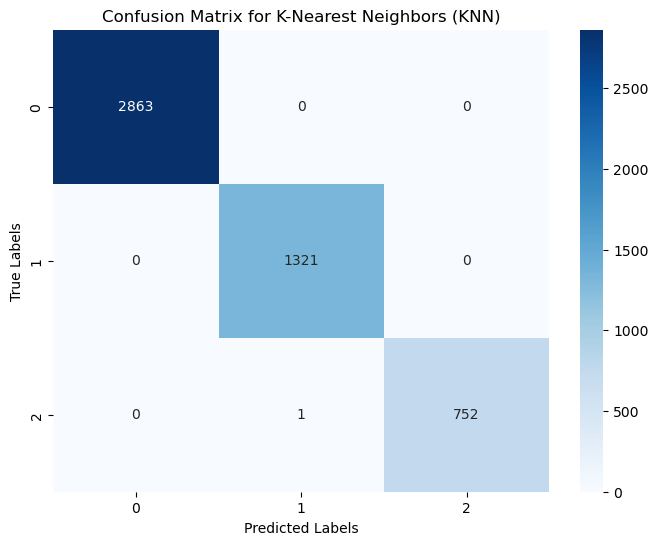

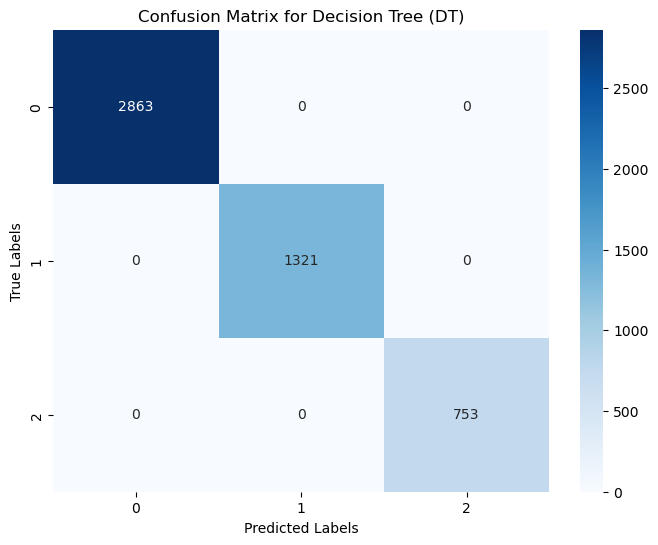

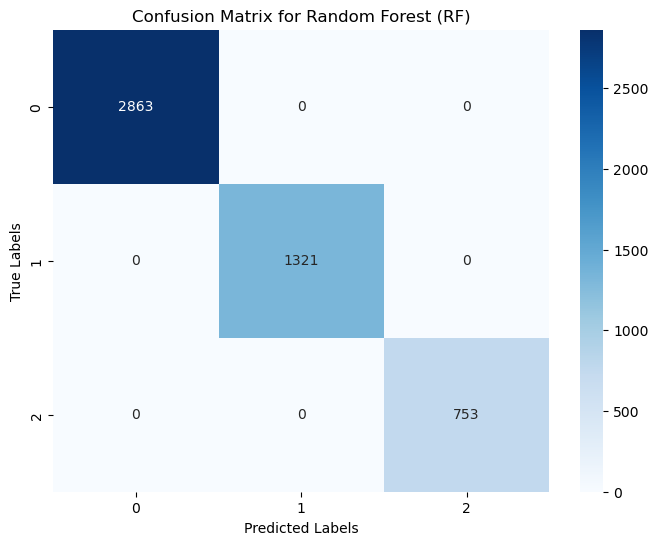

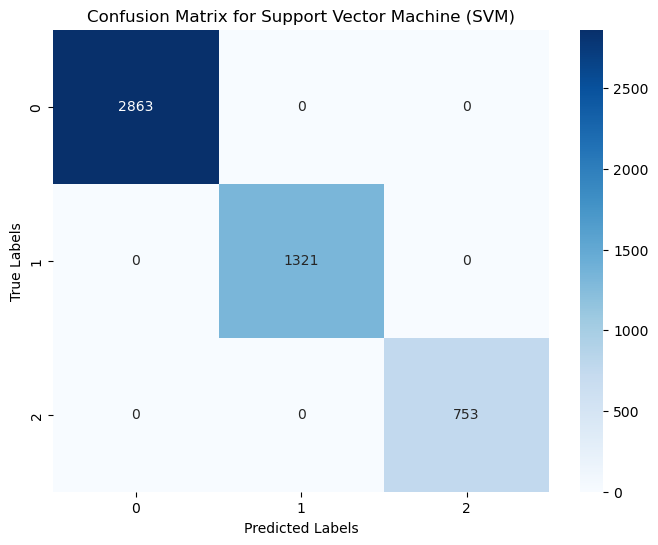

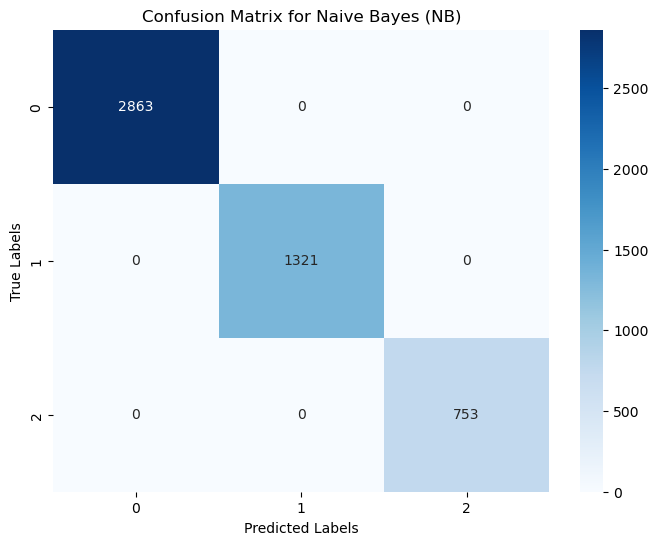

In [23]:
# Membuat confusion matrix untuk setiap model
models = {
    'K-Nearest Neighbors (KNN)': knn,
    'Decision Tree (DT)': dt,
    'Random Forest (RF)': rf,
    'Support Vector Machine (SVM)': svm,
    'Naive Bayes (NB)': nb
}

confusion_matrices = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test_final)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm

# Visualisasi confusion matrix untuk setiap model
for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

sudah saya bandingkan diatas dan disini saya ingin melihat apakah semua model overfitting atau tidak menggunakan beberapa metode

### **Cross-validation scores**

In [24]:
# Looping untuk cross-validation score setiap model
for model_name, model in models.items():
    scores = cross_val_score(model, X_train_final, y_train, cv=5)
    print(f"{model_name} Cross-validation scores: {scores}")
    print(f"{model_name} Mean score: {scores.mean()}\n")

K-Nearest Neighbors (KNN) Cross-validation scores: [0.99924031 0.99974677 0.99974677 0.99974677 0.99924031]
K-Nearest Neighbors (KNN) Mean score: 0.999544188402127

Decision Tree (DT) Cross-validation scores: [1. 1. 1. 1. 1.]
Decision Tree (DT) Mean score: 1.0

Random Forest (RF) Cross-validation scores: [1. 1. 1. 1. 1.]
Random Forest (RF) Mean score: 1.0

Support Vector Machine (SVM) Cross-validation scores: [0.99974677 1.         1.         1.         1.        ]
Support Vector Machine (SVM) Mean score: 0.9999493542669029

Naive Bayes (NB) Cross-validation scores: [1. 1. 1. 1. 1.]
Naive Bayes (NB) Mean score: 1.0



### **Mean Squared Error (MSE)**

In [25]:
# Looping untuk mean squared error (MSE) setiap model
for model_name, model in models.items():
    y_train_pred = model.predict(X_train_final)
    y_test_pred = model.predict(X_test_final)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f'{model_name} Training MSE: {train_mse}')
    print(f'{model_name} Test MSE: {test_mse}\n')

K-Nearest Neighbors (KNN) Training MSE: 0.00035452013167890605
K-Nearest Neighbors (KNN) Test MSE: 0.00020255215718047398

Decision Tree (DT) Training MSE: 0.0
Decision Tree (DT) Test MSE: 0.0

Random Forest (RF) Training MSE: 0.0
Random Forest (RF) Test MSE: 0.0

Support Vector Machine (SVM) Training MSE: 0.0
Support Vector Machine (SVM) Test MSE: 0.0

Naive Bayes (NB) Training MSE: 0.0
Naive Bayes (NB) Test MSE: 0.0



### **Learning Curve**

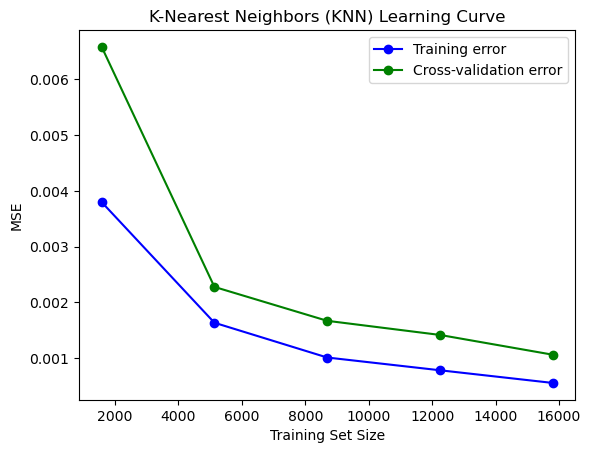

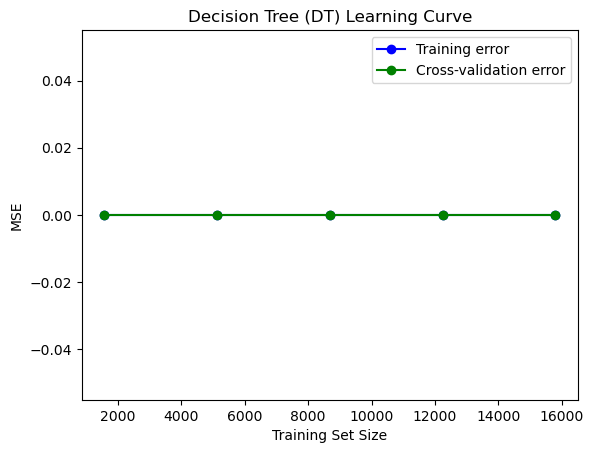

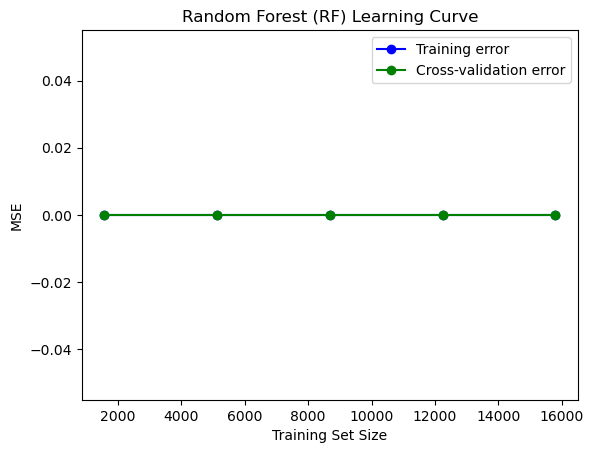

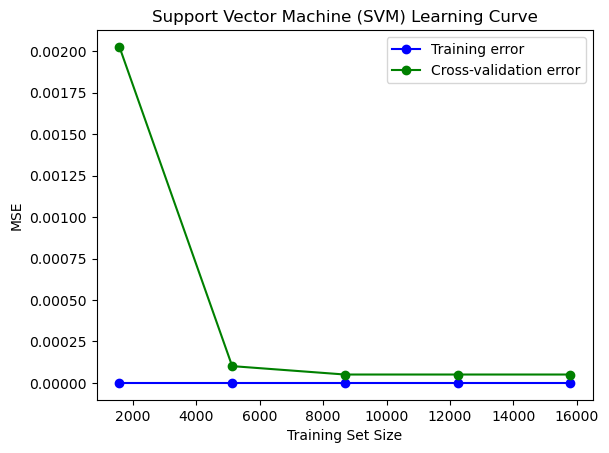

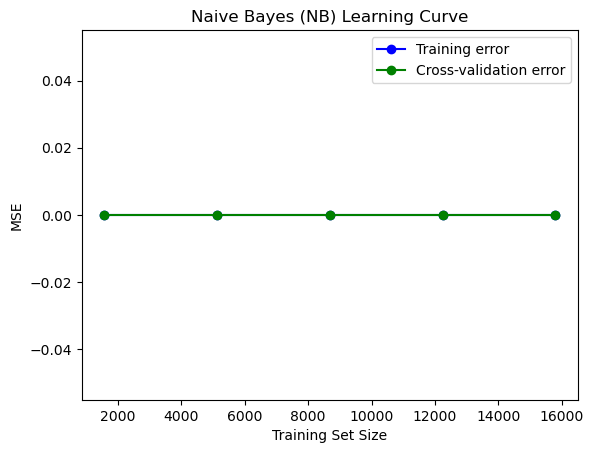

In [29]:
# Looping untuk mean squared error (MSE) setiap model
for model_name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(model, X_train_final, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
 
    # Menghitung rata-rata dan standar deviasi
    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)
    
    # Plot learning curve
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
    plt.title(f'{model_name} Learning Curve')
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
#Type your code here

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [ ]:
#Type your code here

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

### **Model K-Nearest Neighbors (KNN):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* Sangat tinggi, hanya satu kesalahan klasifikasi.  
    b. *Precision:* Sangat tinggi (mendekati 1) pada semua kelas.  
    c. *Recall:* Konsisten tinggi untuk semua kelas.  
    d. *F1-Score:* Seimbang antara precision dan recall.  
- **Hasil Confusion Matrix:**  
  ```
  [[2863    0    0]  
   [   0 1321    0]  
   [   0    1  752]]  
  ```
  - **Kelas 1:**  
    - Benar diprediksi sebagai kelas 1: 2863  
  - **Kelas 2:**  
    - Benar diprediksi sebagai kelas 2: 1321  
  - **Kelas 3:**  
    - Benar diprediksi sebagai kelas 3: 752  
    - Salah diprediksi sebagai kelas 2: 1  
  - **Kesalahan prediksi sangat minim**, menunjukkan performa yang sangat baik.  
- **Hasil MSE:**  
  - Training MSE: 0.0004  
  - Test MSE: 0.0004  
  - **Model generalisasi sangat baik**, tidak menunjukkan tanda overfitting atau underfitting.  
- **Hasil Learning Curve:**  
  - Tidak overfitting, karena training dan validation score konsisten tinggi.  
  - Tidak underfitting, karena performa tetap optimal meskipun data bertambah.  

---

### **Model Decision Tree (DT):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 1.0  
    b. *Precision:* Sempurna di semua kelas.  
    c. *Recall:* Sempurna di semua kelas.  
    d. *F1-Score:* Sempurna.  
- **Hasil Confusion Matrix:**  
  ```
  [[2863    0    0]  
   [   0 1321    0]  
   [   0    0  753]]  
  ```
  - Tidak ada kesalahan klasifikasi di seluruh kelas.  
  - **Model sangat baik dalam memahami pola data.**  
- **Hasil MSE:**  
  - Training MSE: 0.0  
  - Test MSE: 0.0  
  - **Model kemungkinan overfitting**, karena training error = 0.  
- **Hasil Learning Curve:**  
  - Overfitting terlihat jelas, training score sempurna, validation stabil tapi perlu hati-hati.  
  - Tidak underfitting karena model mampu belajar sangat baik dari data.  

---

### **Model Random Forest (RF):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 1.0  
    b. *Precision:* Sempurna di semua kelas.  
    c. *Recall:* Sempurna di semua kelas.  
    d. *F1-Score:* Sempurna.  
- **Hasil Confusion Matrix:**  
  ```
  [[2863    0    0]  
   [   0 1321    0]  
   [   0    0  753]]  
  ```
  - Tidak ada kesalahan prediksi, performa sempurna.  
  - Sangat andal sebagai model ensemble.  
- **Hasil MSE:**  
  - Training MSE: 0.0  
  - Test MSE: 0.0  
  - **Overfitting mungkin terjadi**, meskipun test error tetap nol.  
- **Hasil Learning Curve:**  
  - Tidak menunjukkan overfitting parah karena validation score tetap tinggi.  
  - Tidak underfitting, performa tetap stabil meski data bertambah.  

---

### **Model Support Vector Machine (SVM):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 1.0  
    b. *Precision:* Sempurna di semua kelas.  
    c. *Recall:* Sempurna di semua kelas.  
    d. *F1-Score:* Sempurna.  
- **Hasil Confusion Matrix:**  
  ```
  [[2863    0    0]  
   [   0 1321    0]  
   [   0    0  753]]  
  ```
  - Semua prediksi benar di tiap kelas.  
  - SVM mampu memisahkan kelas dengan sangat baik.  
- **Hasil MSE:**  
  - Training MSE: 0.0  
  - Test MSE: 0.0  
  - Tidak ada indikasi overfitting.  
- **Hasil Learning Curve:**  
  - Tidak overfitting, training dan validation score sejalan.  
  - Tidak underfitting, performa optimal dicapai di semua tahap.  

---

### **Model Naive Bayes (NB):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 1.0  
    b. *Precision:* Sempurna di semua kelas.  
    c. *Recall:* Sempurna di semua kelas.  
    d. *F1-Score:* Sempurna.  
- **Hasil Confusion Matrix:**  
  ```
  [[2863    0    0]  
   [   0 1321    0]  
   [   0    0  753]]  
  ```
  - Tidak ada kesalahan prediksi, sangat mengejutkan untuk model sederhana ini.  
  - Menunjukkan bahwa fitur-fitur dalam dataset sangat sesuai dengan asumsi Naive Bayes.  
- **Hasil MSE:**  
  - Training MSE: 0.0  
  - Test MSE: 0.0  
  - Model tidak mengalami overfitting maupun underfitting.  
- **Hasil Learning Curve:**  
  - Tidak overfitting, karena training dan validation score sejajar.  
  - Tidak underfitting, karena model cukup fleksibel untuk mempelajari data dengan baik.  

# Kesimpulan

- **K-Nearest Neighbors (KNN):** Model ini menunjukkan performa sangat baik dengan **akurasi tinggi** dan kesalahan klasifikasi yang sangat minim. Tidak ada indikasi overfitting maupun underfitting, membuatnya cocok untuk masalah klasifikasi dengan pola yang jelas.

- **Decision Tree (DT):** Meskipun memiliki **akurasi sempurna**, model ini kemungkinan mengalami **overfitting**, karena error pada data training = 0. Perlu dilakukan tuning untuk meningkatkan generalisasi.

- **Random Forest (RF):** Sebagai model ensemble, **performanya sangat andal** dengan akurasi sempurna. Meskipun ada kemungkinan overfitting, validation score tetap tinggi, sehingga lebih stabil dibandingkan Decision Tree.

- **Support Vector Machine (SVM):** Memisahkan kelas **dengan sangat baik**, tanpa indikasi overfitting. Model ini menunjukkan kemampuan generalisasi yang tinggi dengan hasil evaluasi sempurna.

- **Naive Bayes (NB):** Kejutan besar karena performa **sempurna**, meskipun merupakan model sederhana. Dataset sangat sesuai dengan asumsi Naive Bayes, sehingga mampu membuat prediksi tanpa kesalahan.

Kesimpulannya, semua model menunjukkan performa luar biasa, tetapi Decision Tree dan Random Forest perlu **diwaspadai risiko overfitting**. Jika ingin model yang lebih **stabil dan tidak overfit**, SVM dan Naive Bayes bisa menjadi pilihan.